# Run matched filters in EMIT product

Example from work:
>  V. Růžička, G. Mateo-Garcia, L. Gómez-Chova, A. Vaughan, L. Guanter, and A. Markham, [Semantic segmentation of methane plumes with hyperspectral machine learning models](https://www.nature.com/articles/s41598-023-44918-6). _Scientific Reports 13, 19999_ (2023). DOI: 10.1038/s41598-023-44918-6.



## Step 1: download EMIT image

In order to download and process the EMIT image we will use the emit reader in the [georeader](https://github.com/spaceml-org/georeader/) package. See [this tutorial](https://spaceml-org.github.io/georeader/emit_explore/) for an example of how to load and plot the data.

In [1]:
import georeader
from georeader.readers import emit, download_utils
from georeader import plot
import os
import numpy as np
import matplotlib.pyplot as plt

link = emit.get_radiance_link("EMIT_L1B_RAD_001_20220827T060753_2223904_013.nc")

earthdata_nasa_account = True

# NASA's data archive requires creating an account for downloading EMIT files directly.
# Create an user and a token at the NASA Earthdata portal (https://urs.earthdata.nasa.gov/profile)

if earthdata_nasa_account:
    emit.AUTH_METHOD = "token"
    emit.TOKEN = "eyJ0..." # copy your token here
    headers = {"Authorization": f"Bearer {emit.TOKEN}"}
    
    product = download_utils.download_product(link, headers=headers,  verify=True)
    
    rst = emit.EMITImage(product)
else:
    # alernatively for the sake of this demo, we also uploaded this scene on our gdrive (but if these two files are missing, please use the above download instead)
    !gdown 1jyFejO80Q82qUZ5tRPaDTqsBHefuXYa0
    !gdown 1a9k2YZDXfa4g95KlqCcKfkYcaA-QegYU
    !ls
    
    rst = emit.EMITImage("EMIT_L1B_RAD_001_20220827T060753_2223904_013.nc")
rst

/home/gonzalo/git/mars_mf/.venv/lib/python3.10/site-packages/georeader/reflectance.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


File EMIT_L1B_RAD_001_20220827T060753_2223904_013.nc exists. It won't be downloaded again


 
         File: EMIT_L1B_RAD_001_20220827T060753_2223904_013.nc
         Transform: | 0.00,-0.00, 61.16|
|-0.00,-0.00, 36.83|
| 0.00, 0.00, 1.00|
         Shape: (285, 2007, 2239)
         Resolution: (0.0005422325202530942, 0.0005422325202530942)
         Bounds: (np.float64(61.1592142222353), np.float64(35.74201728362127), np.float64(62.3732728350893), np.float64(36.8302779517758))
         CRS: EPSG:4326
         units: uW/cm^2/SR/nm
        

## Run mag1c retrieval on the EMIT product

Run mag1c filter retrieval based on the work of [Foote et al. 2020](https://ieeexplore.ieee.org/document/9034492).

In [2]:
from mars_mf.emit import mag1c_emit

mfoutput, albedo = mag1c_emit.mag1c_emit(rst, column_step=4, georeferenced=False)
mfoutput

	Running mag1c filter by columns: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 311/311 [00:31<00:00,  9.90it/s]


array([[  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       [  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       [395.65817,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       ...,
       [  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
        363.98874],
       [  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ],
       [  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
          0.     ]], shape=(1280, 1242), dtype=float32)

Plot results on satellite coordinates:

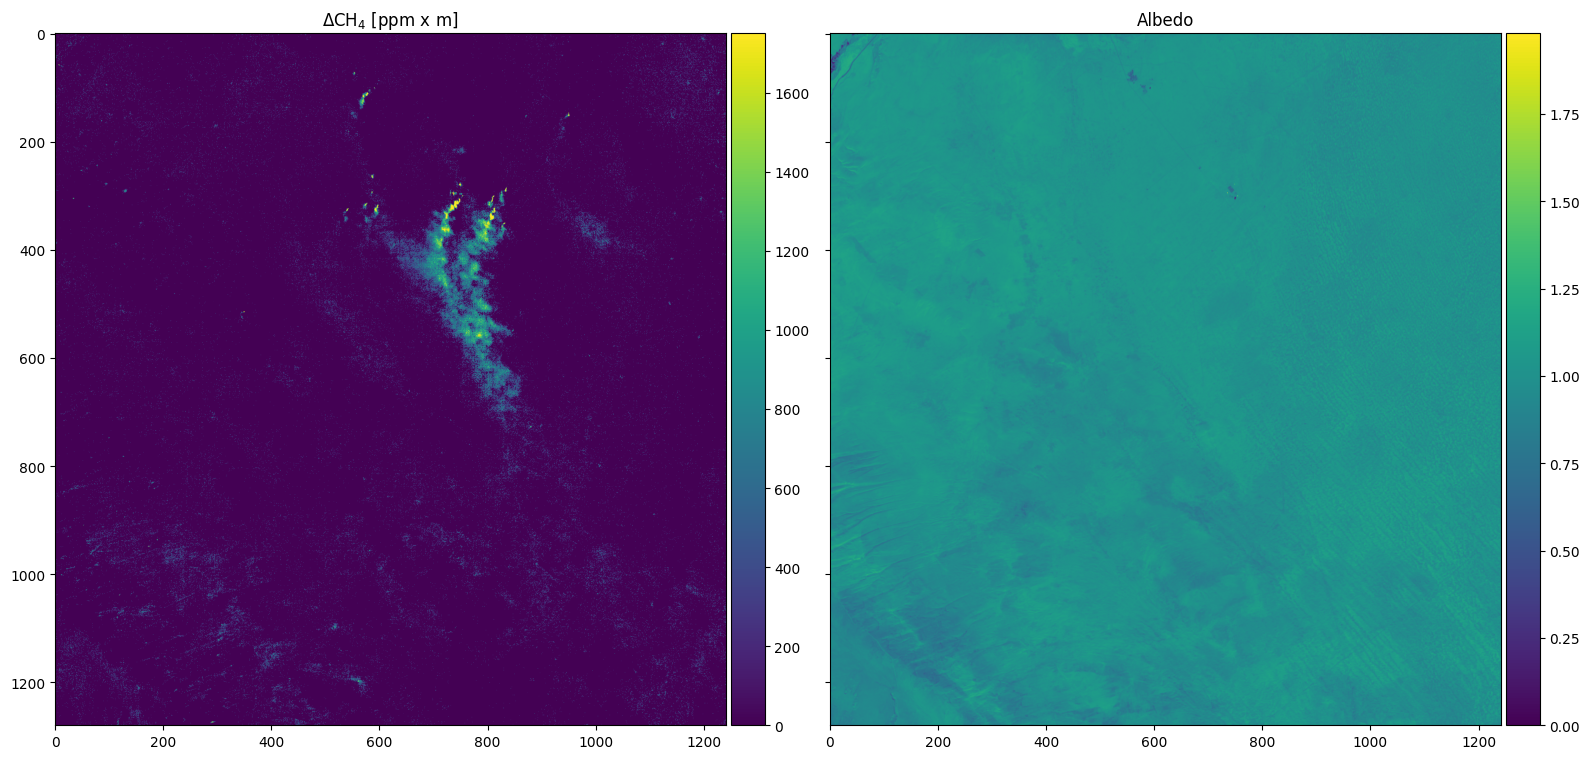

In [3]:
fig, ax = plt.subplots(1,2, figsize=(16,8), tight_layout=True, sharey=True)
im = ax[0].imshow(mfoutput, vmin=0,vmax=1750)
ax[0].set_title("$\Delta$CH$_4$ [ppm x m]")
plot.colorbar_next_to(im, ax[0])

im = ax[1].imshow(albedo, vmin=0)
ax[1].set_title("Albedo")
plot.colorbar_next_to(im, ax[1])

## Run WMF retrieval on EMIT product

Run wide matched filter retrieval based on the work of [Roger et al. 2024](https://doi.org/10.5194/amt-17-1333-2024).

In [4]:
from mars_mf.emit import retrieval_upv_emit


mf_classic, mf_extended, mf_combo, mf_extended_filtered, rad = retrieval_upv_emit.AT_MF_total_EMIT(rst, georeferenced=False) # georreferenced=False

VZA: 9.62639331817627, SZA: 35.64642333984375


Plot results on satellite coordinates:

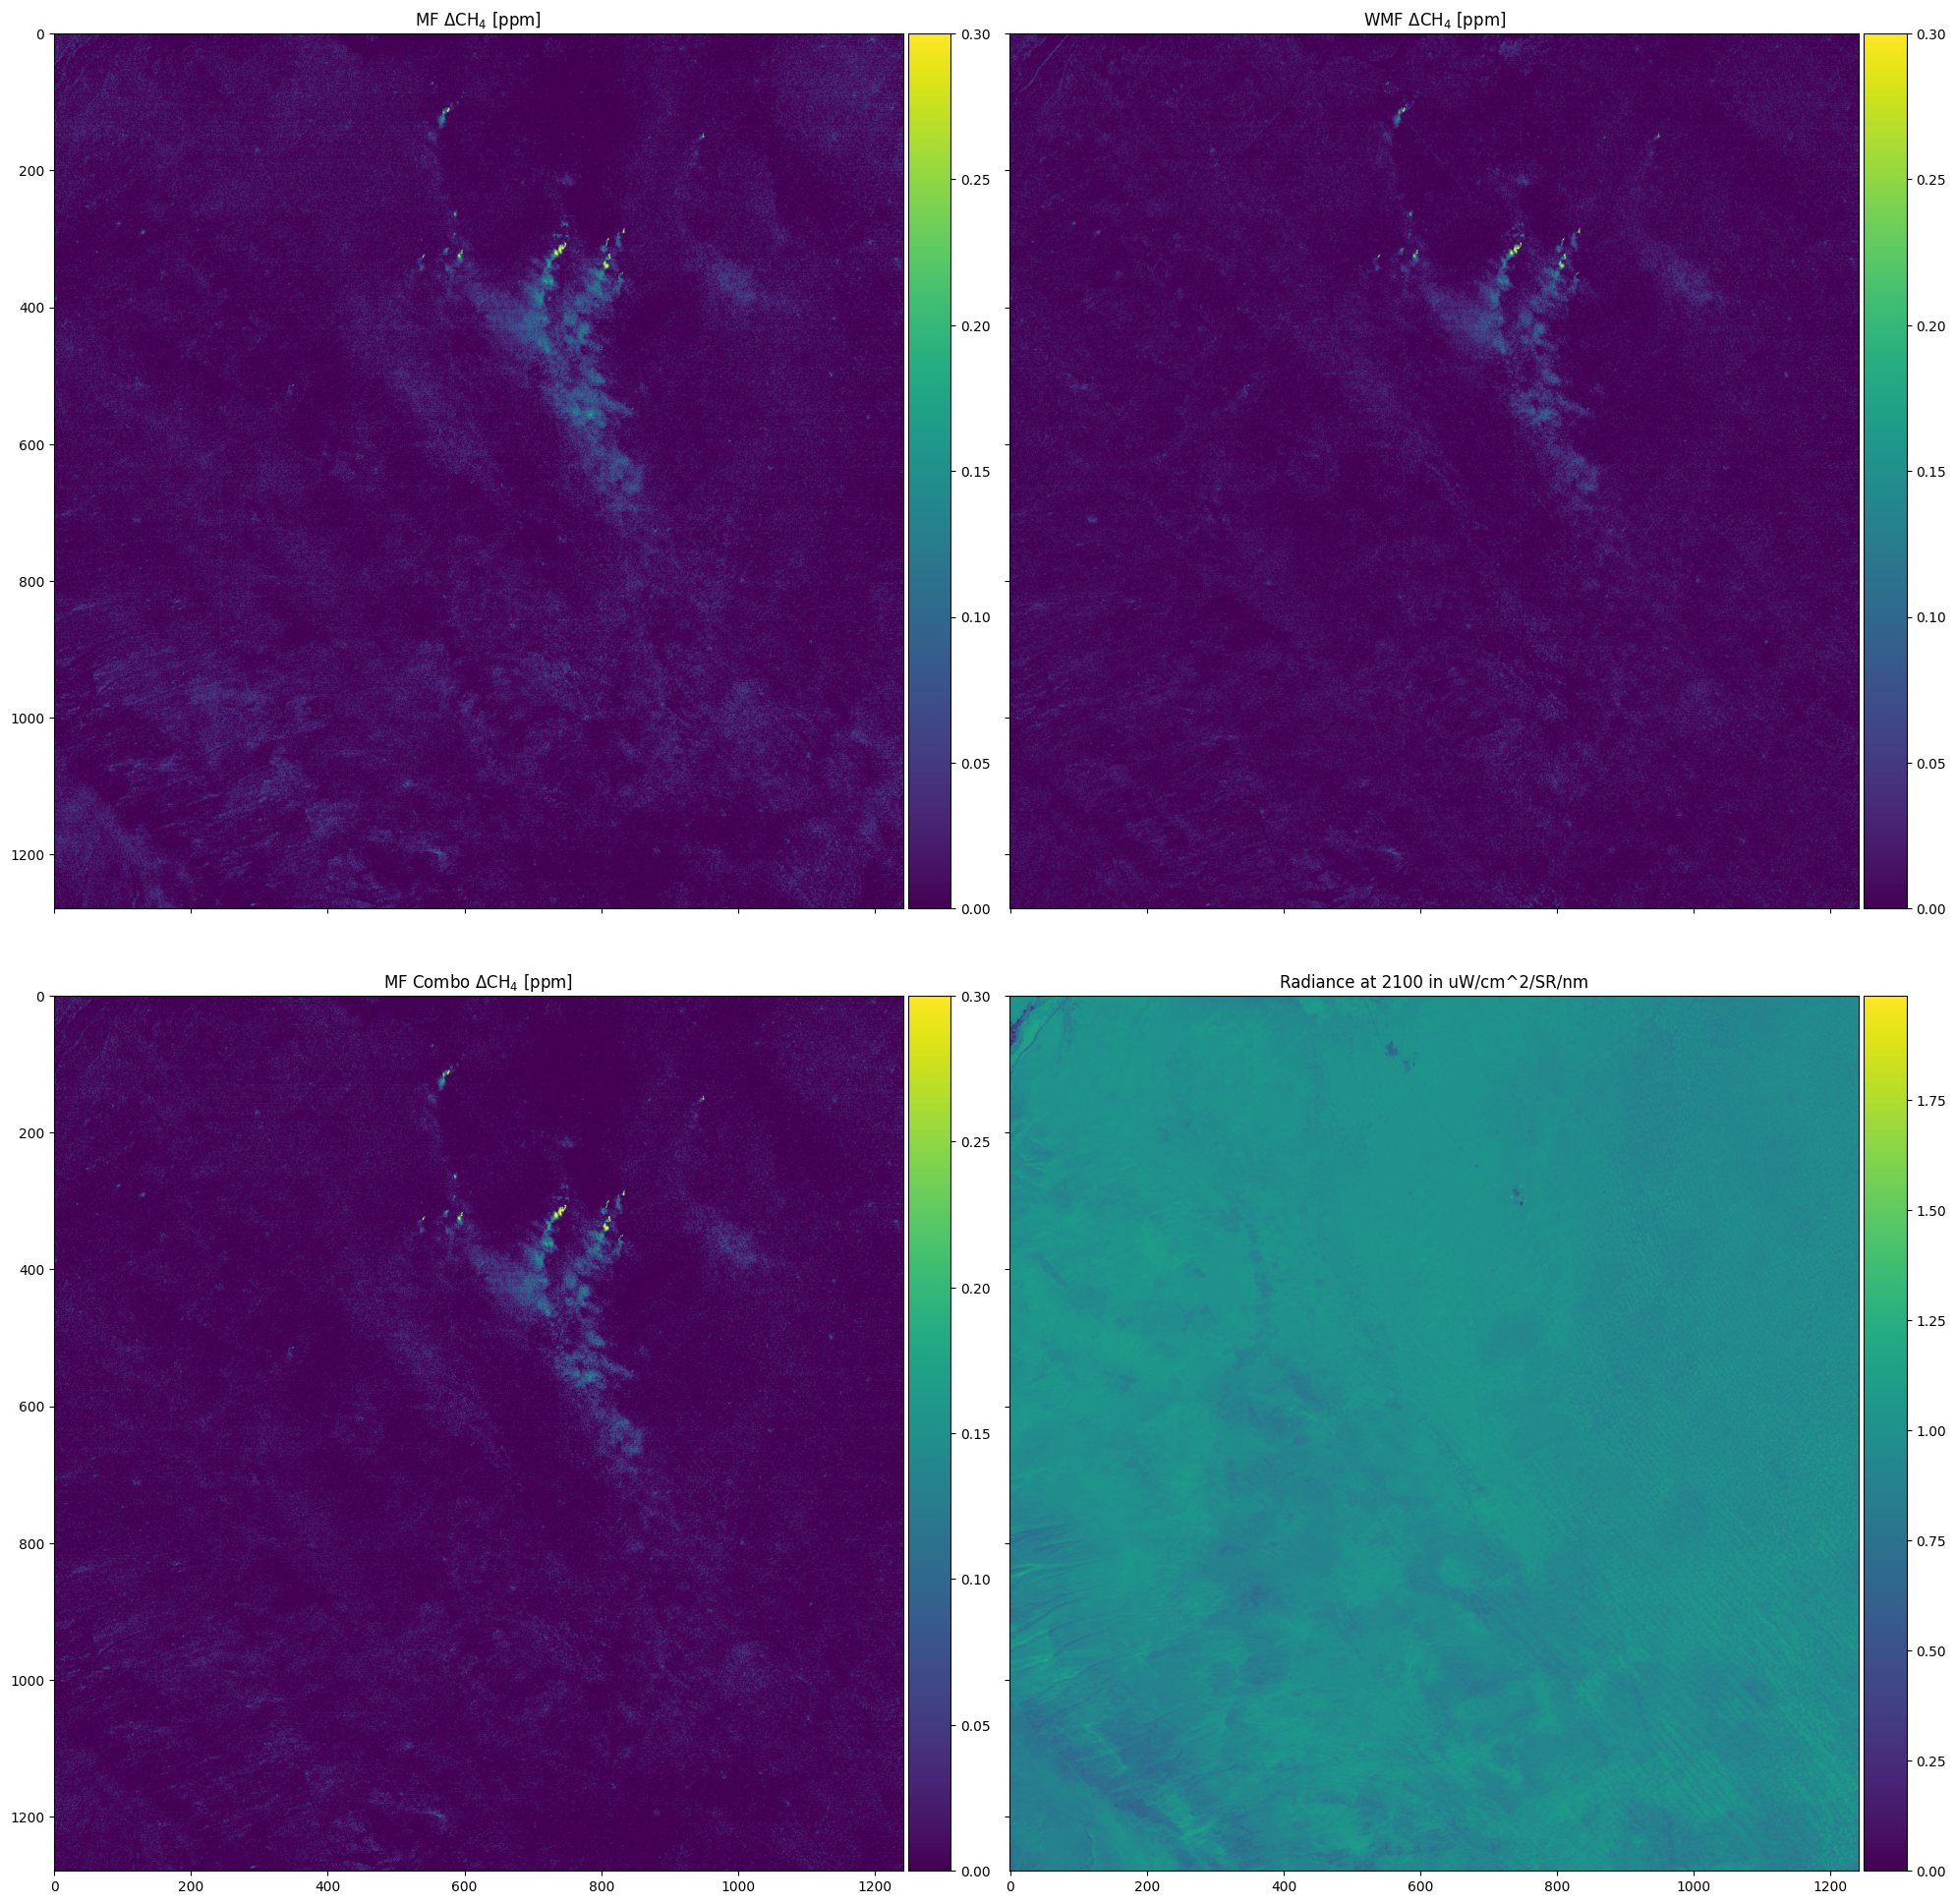

In [9]:
fig, ax = plt.subplots(2,2, figsize=(20,20), tight_layout=True, sharey=True, sharex=True)

axi = ax[0,0]
im = axi.imshow(mf_classic, vmin=0,vmax=0.3)
axi.set_title("MF $\Delta$CH$_4$ [ppm]")
plot.colorbar_next_to(im, axi)

axi = ax[0,1]
im = axi.imshow(mf_extended, vmin=0,vmax=0.3)
axi.set_title("WMF $\Delta$CH$_4$ [ppm]")
plot.colorbar_next_to(im, axi)

axi = ax[1,0]
im = axi.imshow(mf_combo, vmin=0,vmax=0.3)
axi.set_title("MF Combo $\Delta$CH$_4$ [ppm]")
plot.colorbar_next_to(im, axi)

# rad
axi = ax[1,1]
im = axi.imshow(rad, vmin=0)
axi.set_title(f"Radiance at {retrieval_upv_emit.RAD_WAVELENGTH} in {rst.units}")
plot.colorbar_next_to(im, axi)

## Georreference to UTM

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9999.0..1.0].


<Axes: title={'center': 'WMF $\\Delta$CH$_4$ [ppm]'}>

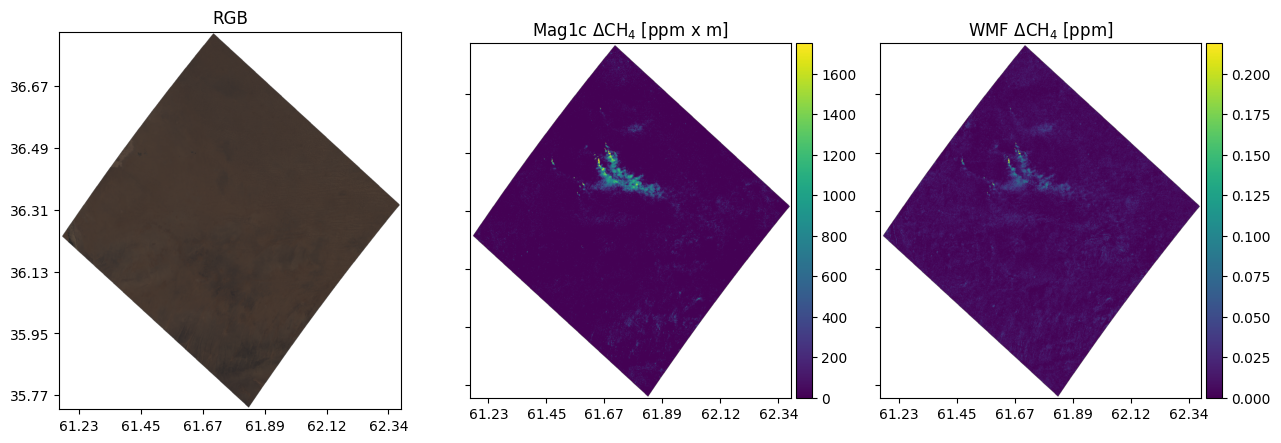

In [15]:
crs_utm = georeader.get_utm_epsg(rst.footprint("EPSG:4326"))
emit_image_utm = rst.to_crs(crs_utm)

rgb = emit_image_utm.load_rgb(as_reflectance=True)

fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=True)

mag1c_geo = emit_image_utm.georreference(mfoutput, fill_value_default=-1)
wmf_geo = emit_image_utm.georreference(mf_extended, fill_value_default=-1)

plot.show(rgb, ax=ax[0], title= "RGB",mask=True) # add_scalebar=True -> pip install matplotlib_scalebar
plot.show(mag1c_geo, ax=ax[1], title= "Mag1c $\Delta$CH$_4$ [ppm x m]",mask=True,vmin=0, vmax=1750,
         add_colorbar_next_to=True)
plot.show(wmf_geo, ax=ax[2], title= "WMF $\Delta$CH$_4$ [ppm]", mask=True, vmin=0, vmax=1750/8_000, 
          add_colorbar_next_to=True)

The mars_mf package and tutorials are released under a [Creative Commons non-commercial Share-Alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt). For using the codes in comercial pipelines written consent by the authors must be provided.

 If you find this work useful please cite:
```
@article{ruzicka_starcop_2023,
	title = {Semantic segmentation of methane plumes with hyperspectral machine learning models},
	volume = {13},
	issn = {2045-2322},
	url = {https://www.nature.com/articles/s41598-023-44918-6},
	doi = {10.1038/s41598-023-44918-6},
	number = {1},
	journal = {Scientific Reports},
	author = {Růžička, Vít and Mateo-Garcia, Gonzalo and Gómez-Chova, Luis and Vaughan, Anna, and Guanter, Luis and Markham, Andrew},
	month = nov,
	year = {2023},
	pages = {19999}
}
```